/home/tatsushi/デスクトップ/chemosensitivity_gastric_cancer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


===== load models =====
device: cuda
ViT cutoff  : 0.4000
EVA02 cutoff: 0.3500

===== collect image files =====
root   : /home/tatsushi/デスクトップ/sensitivity_data7/image-sens/mucosa/external
0_sens : 127
2_resis: 355
total  : 482

===== inference =====
[0001/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0001.JPG
[0002/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0002.JPG
[0003/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0003.JPG
[0004/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0004.JPG
[0005/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0005.JPG
[0006/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0006.JPG
[0007/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0007.JPG
[0008/0482] 0_sens | ViT=1.0000 | EVA02=1.0000 | 000_1-0-EBV-0008.JPG
[0009/0482] 0_sens | ViT=0.5003 | EVA02=1.0000 | 201_1-0-Fujikawa-0001.jpg
[0010/0482] 0_sens | ViT=0.9819 | EVA02=0.9998 | 201_1-0-Fujikawa-0002.jpg
[0011/0482] 0_sens | ViT=0.9319 | EVA02=

/tmp/ipykernel_193567/2432299180.py:324: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_193567/2432299180.py:324: UserWarning: Glyph 12424 (\N{HIRAGANA LETTER YO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_193567/2432299180.py:324: UserWarning: Glyph 12427 (\N{HIRAGANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_193567/2432299180.py:324: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_193567/2432299180.py:324: UserWarning: Glyph 35542 (\N{CJK UNIFIED IDEOGRAPH-8AD6}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_193567/2432299180.py:324: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_193567/2432299180.py:325: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing f

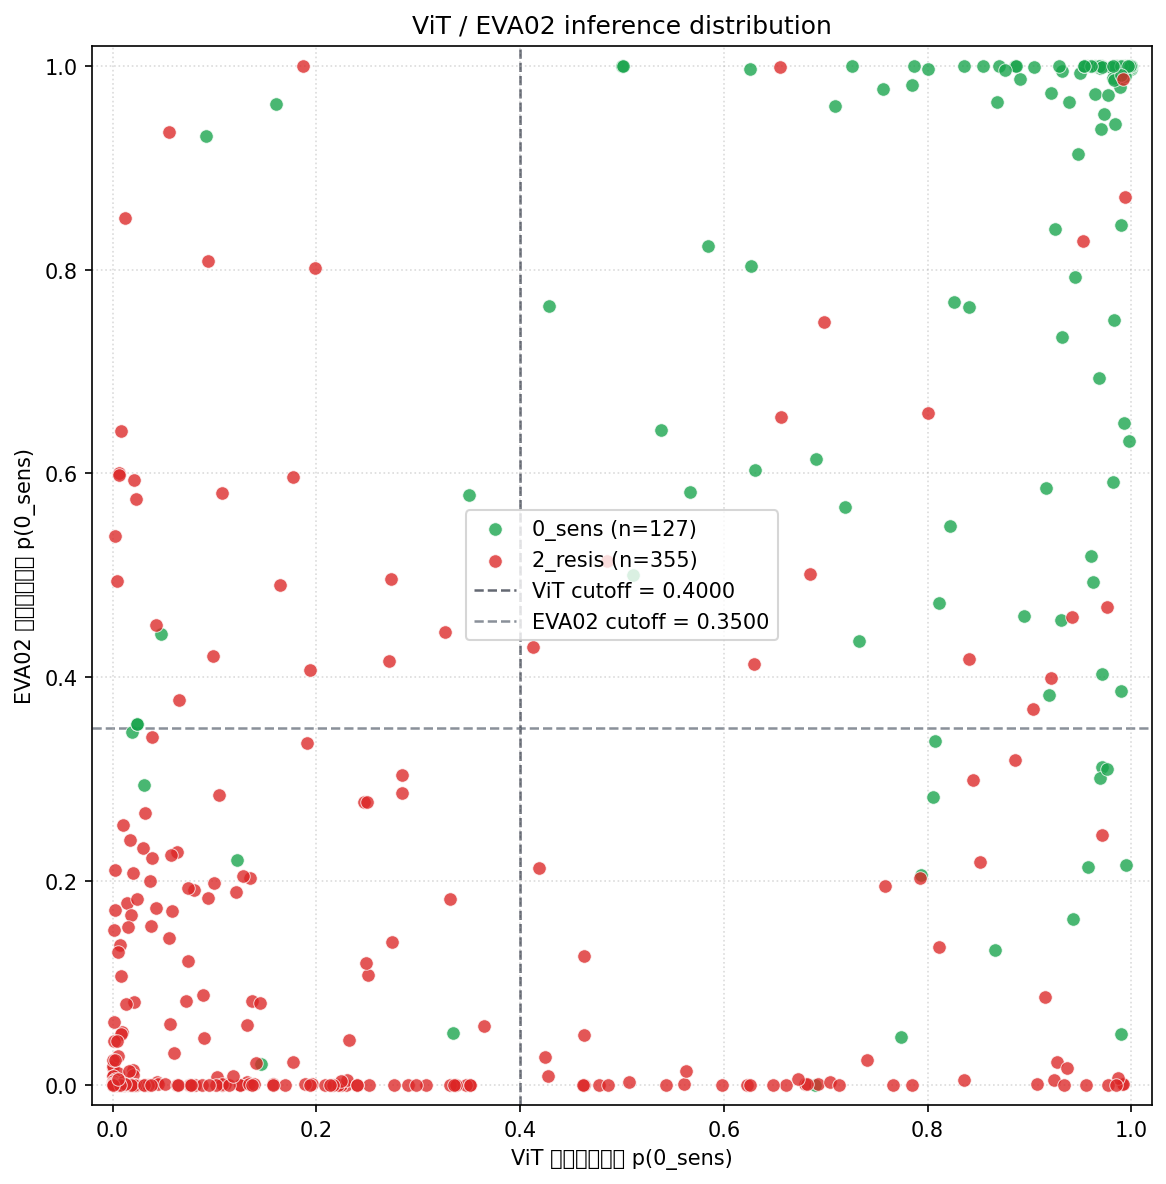

saved: /home/tatsushi/デスクトップ/chemosensitivity_gastric_cancer/bunnpu.png


In [1]:
# 胃癌の化学療法感受性を ViT-CLS と EVA02-AVG で推論し、0_sens / 2_resis の分布図を作成する

#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
入力した親フォルダーの下層にある 0_sens / 2_resis フォルダー内の画像を推論し、
横軸を ViT の推論値、縦軸を EVA02 の推論値として分布図を表示・保存する。

- 0_sens フォルダー内の画像: 緑
- 2_resis フォルダー内の画像: 赤
- ViT / EVA02 それぞれの cutoff: 破線
- 保存先: ./bunnpu.png
"""

import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import tkinter as tk
from tkinter import filedialog
from PIL import Image
import timm
from timm.data import resolve_data_config, create_transform


# ここに親フォルダーのパスを文字列で入れると、ダイアログを使わずに実行できます。
# 空文字のままならフォルダー選択ダイアログを表示します。
TARGET_ROOT = "/home/tatsushi/デスクトップ/sensitivity_data7/image-sens/mucosa/external"
OUTPUT_PATH = Path("./bunnpu.png")

VALID_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass(frozen=True)
class BackendSpec:
    name: str
    ensemble_info_path: Path
    feature_model_name: str
    img_size: int
    pooling: str


VIT_SPEC = BackendSpec(
    name="ViT",
    ensemble_info_path=Path(
        "/home/tatsushi/デスクトップ/cls_avg_result/vit_large_patch16_616.augreg_in21k_ft_in1k-100/vit_large_patch16_616.augreg_in21k_ft_in1k/Vit_fixed_val_classes_models_0sens_positive/top5_ensemble_info.pth"
    ),
    feature_model_name="vit_large_patch16_384.augreg_in21k_ft_in1k",
    img_size=616,
    pooling="cls",
)

EVA02_SPEC = BackendSpec(
    name="EVA02",
    ensemble_info_path=Path(
        "/home/tatsushi/デスクトップ/cls_avg_result/eva02_large_patch14_448.mim_in22k_ft_in22k_avg-100/eva02_large_patch14_448.mim_in22k_ft_in22k/Vit_fixed_val_classes_models_0sens_positive/top5_ensemble_info.pth"
    ),
    feature_model_name="eva02_large_patch14_448.mim_in22k_ft_in22k",
    img_size=448,
    pooling="avg_patch_tokens",
)


class MLPClassifier(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 256, num_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def torch_load_safe(path, map_location="cpu"):
    return torch.load(path, map_location=map_location, weights_only=False)


def select_target_root() -> Path:
    if TARGET_ROOT:
        selected = Path(TARGET_ROOT).expanduser()
    else:
        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        selected_text = filedialog.askdirectory(title="0_sens / 2_resis を含む親フォルダーを選択してください")
        root.destroy()
        if not selected_text:
            raise ValueError("フォルダーが選択されませんでした。処理を終了します。")
        selected = Path(selected_text)

    if not selected.exists():
        raise FileNotFoundError(f"フォルダーが存在しません: {selected}")
    if not selected.is_dir():
        raise NotADirectoryError(f"フォルダーではありません: {selected}")
    return selected


def collect_labeled_image_files(root_folder: Path):
    rows = []
    seen = set()
    label_specs = {
        "0_sens": {"class_name": "0_sens", "color": "green"},
        "2_resis": {"class_name": "2_resis", "color": "red"},
    }

    label_dirs = []
    for current_root, dirnames, _ in os.walk(root_folder):
        current_path = Path(current_root)
        if current_path.name in label_specs:
            label_dirs.append(current_path)

    for label_dir in sorted(label_dirs):
        class_name = label_dir.name
        for image_path in sorted(label_dir.rglob("*")):
            if not image_path.is_file() or image_path.suffix.lower() not in VALID_EXT:
                continue
            resolved = image_path.resolve()
            if resolved in seen:
                continue
            seen.add(resolved)
            rows.append(
                {
                    "path": image_path,
                    "class_name": class_name,
                    "color": label_specs[class_name]["color"],
                }
            )

    if len(rows) == 0:
        raise ValueError(f"0_sens / 2_resis フォルダー内に画像ファイルが見つかりません: {root_folder}")
    return rows


def center_crop_max_square(img: Image.Image) -> Image.Image:
    w, h = img.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    return img.crop((left, top, left + side, top + side))


def load_ensemble_models(ensemble_info_path: Path, device):
    info = torch_load_safe(ensemble_info_path, map_location="cpu")
    topk_model_paths = info["topk_model_paths"]
    cutoff = float(info.get("ensemble_best_cutoff", 0.5))

    models = []
    for model_path in topk_model_paths:
        ckpt = torch_load_safe(model_path, map_location="cpu")
        model = MLPClassifier(in_dim=ckpt["input_dim"]).to(device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        models.append(model)

    return models, cutoff, info


def load_feature_extractor(spec: BackendSpec, device):
    feat_model = timm.create_model(spec.feature_model_name, pretrained=True, num_classes=0)
    feat_model.to(device).eval()
    for p in feat_model.parameters():
        p.requires_grad = False

    if hasattr(feat_model, "set_input_size"):
        feat_model.set_input_size(img_size=spec.img_size)
    else:
        raise RuntimeError(
            f"{spec.name}: This model does not support set_input_size(). "
            "Please update timm or use another model."
        )

    data_cfg = resolve_data_config({}, model=feat_model)
    data_cfg["input_size"] = (3, spec.img_size, spec.img_size)
    data_cfg["crop_pct"] = 1.0
    transform = create_transform(**data_cfg)
    return feat_model, transform


def load_backend(spec: BackendSpec, device):
    feat_model, transform = load_feature_extractor(spec, device)
    models, cutoff, info = load_ensemble_models(spec.ensemble_info_path, device)
    return {
        "spec": spec,
        "feat_model": feat_model,
        "transform": transform,
        "models": models,
        "cutoff": cutoff,
        "info": info,
    }


@torch.no_grad()
def extract_feature(model, x: torch.Tensor, pooling: str) -> torch.Tensor:
    feats = model.forward_features(x) if hasattr(model, "forward_features") else model(x)

    if feats.ndim == 3:
        if pooling == "cls":
            return feats[:, 0]
        if pooling == "avg_patch_tokens":
            if feats.shape[1] > 1:
                return feats[:, 1:].mean(dim=1)
            return feats.mean(dim=1)
        raise ValueError(f"未知のpoolingです: {pooling}")

    if feats.ndim == 4:
        return feats.mean(dim=(2, 3))
    return feats


@torch.no_grad()
def predict_with_backend(backend, cropped_img: Image.Image):
    spec = backend["spec"]
    x_img = backend["transform"](cropped_img).unsqueeze(0).to(DEVICE)
    feat_1d = (
        extract_feature(backend["feat_model"], x_img, spec.pooling)
        .squeeze(0)
        .float()
        .reshape(-1)
    )

    expected_dim = backend["models"][0].net[0].in_features
    if feat_1d.numel() != expected_dim:
        raise ValueError(
            f"{spec.name}: 特徴次元不一致 expected={expected_dim}, got={feat_1d.numel()}"
        )

    x = feat_1d.unsqueeze(0).to(DEVICE)
    prob_list = []
    for model in backend["models"]:
        out = model(x)
        proba = torch.softmax(out, dim=1)[:, 1]
        prob_list.append(proba.item())

    return float(np.mean(prob_list))


def run_inference(rows, vit_backend, eva_backend):
    results = []
    for i, row in enumerate(rows, start=1):
        image_path = row["path"]
        try:
            img = Image.open(image_path).convert("RGB")
            cropped_img = center_crop_max_square(img)
            vit_prob = predict_with_backend(vit_backend, cropped_img)
            eva_prob = predict_with_backend(eva_backend, cropped_img)
        except Exception as e:
            print(f"[{i:04d}/{len(rows):04d}] SKIP: {image_path} | {e}")
            continue

        result = dict(row)
        result["vit_prob"] = vit_prob
        result["eva_prob"] = eva_prob
        results.append(result)
        print(
            f"[{i:04d}/{len(rows):04d}] {row['class_name']} | "
            f"ViT={vit_prob:.4f} | EVA02={eva_prob:.4f} | {image_path.name}"
        )

    if len(results) == 0:
        raise RuntimeError("有効な画像を1件も処理できませんでした。")
    return results


def plot_distribution(results, vit_cutoff: float, eva_cutoff: float, output_path: Path):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

    for class_name, color, label in [
        ("0_sens", "#16a34a", "0_sens"),
        ("2_resis", "#dc2626", "2_resis"),
    ]:
        class_rows = [r for r in results if r["class_name"] == class_name]
        if not class_rows:
            continue
        ax.scatter(
            [r["vit_prob"] for r in class_rows],
            [r["eva_prob"] for r in class_rows],
            c=color,
            label=f"{label} (n={len(class_rows)})",
            alpha=0.78,
            edgecolors="white",
            linewidths=0.45,
            s=42,
            zorder=3,
        )

    # cutoff 線は点の背面に薄く描き、分布が隠れないようにする。
    ax.axvline(
        vit_cutoff,
        color="#111827",
        linestyle="--",
        linewidth=1.2,
        alpha=0.65,
        label=f"ViT cutoff = {vit_cutoff:.4f}",
        zorder=1,
    )
    ax.axhline(
        eva_cutoff,
        color="#4b5563",
        linestyle="--",
        linewidth=1.2,
        alpha=0.65,
        label=f"EVA02 cutoff = {eva_cutoff:.4f}",
        zorder=1,
    )

    ax.set_xlabel("ViT による推論値 p(0_sens)")
    ax.set_ylabel("EVA02 による推論値 p(0_sens)")
    ax.set_title("ViT / EVA02 inference distribution")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.45, zorder=0)
    ax.legend(loc="best", frameon=True)
    ax.set_aspect("equal", adjustable="box")

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"saved: {output_path.resolve()}")


def main():
    target_root = select_target_root()
    print("===== load models =====")
    print(f"device: {DEVICE}")
    vit_backend = load_backend(VIT_SPEC, DEVICE)
    eva_backend = load_backend(EVA02_SPEC, DEVICE)
    print(f"ViT cutoff  : {vit_backend['cutoff']:.4f}")
    print(f"EVA02 cutoff: {eva_backend['cutoff']:.4f}")

    print("\n===== collect image files =====")
    rows = collect_labeled_image_files(target_root)
    n_sens = sum(r["class_name"] == "0_sens" for r in rows)
    n_resis = sum(r["class_name"] == "2_resis" for r in rows)
    print(f"root   : {target_root}")
    print(f"0_sens : {n_sens}")
    print(f"2_resis: {n_resis}")
    print(f"total  : {len(rows)}")

    print("\n===== inference =====")
    results = run_inference(rows, vit_backend, eva_backend)

    print("\n===== plot =====")
    plot_distribution(
        results=results,
        vit_cutoff=vit_backend["cutoff"],
        eva_cutoff=eva_backend["cutoff"],
        output_path=OUTPUT_PATH,
    )


if __name__ == "__main__":
    main()
